# Argoverse 2 Motion Forecasting — Scenario Visualizer
Reads AV2 scenario parquet files and visualizes map features and agent trajectories using the `av2` API directly.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
from pathlib import Path

from av2.datasets.motion_forecasting.scenario_serialization import load_argoverse_scenario_parquet
from av2.datasets.motion_forecasting.data_schema import ObjectType, TrackCategory
from av2.map.map_api import ArgoverseStaticMap
from av2.map.lane_segment import LaneMarkType, LaneType

%matplotlib widget
print('Imports OK')

Imports OK


In [30]:
"""Configuration — adjust paths here."""
import glob

# DATA_ROOT = Path('../av2_test')   # path to the AV2 data split (train/val/test)
DATA_ROOT = Path('~/data/av2_motion/').expanduser()   # path to the AV2 data split (train/val/test)
SPLIT     = 'val'   # 'train' | 'val' | 'test'

scenario_dirs = sorted(
    d for d in (DATA_ROOT / SPLIT).iterdir()
    if d.is_dir()
)
print(f'Found {len(scenario_dirs)} scenarios in split "{SPLIT}"')

SCENARIO_IDX = 18   # which scenario to load

Found 24988 scenarios in split "val"


In [31]:
"""Load one scenario."""
# scenario_dir = scenario_dirs[SCENARIO_IDX]
# print(scenario_dirs)
scenario_dir = DATA_ROOT / SPLIT / '0015197d-b916-43b6-bcaa-8a7d90d7b87d'
scenario_id  = scenario_dir.name
parquet_file = scenario_dir / f'scenario_{scenario_id}.parquet'

print(f'Loading: {parquet_file}')
scenario = load_argoverse_scenario_parquet(parquet_file)
avm      = ArgoverseStaticMap.from_map_dir(scenario_dir, build_raster=False)

n_tracks    = len(scenario.tracks)
n_timesteps = len(scenario.timestamps_ns)
lanes       = avm.get_scenario_lane_segments()
ped_xings   = avm.get_scenario_ped_crossings()
driv_areas  = avm.get_scenario_vector_drivable_areas()

print(f'Scenario ID   : {scenario.scenario_id}')
print(f'City          : {scenario.city_name}')
print(f'Focal track   : {scenario.focal_track_id}')
print(f'Timesteps     : {n_timesteps}')
print(f'Tracks        : {n_tracks}')
print(f'Lane segments : {len(lanes)}')
print(f'Ped crossings : {len(ped_xings)}')
print(f'Drivable areas: {len(driv_areas)}')

Loading: /home/mpatil/data/av2_motion/val/0015197d-b916-43b6-bcaa-8a7d90d7b87d/scenario_0015197d-b916-43b6-bcaa-8a7d90d7b87d.parquet
Scenario ID   : 0015197d-b916-43b6-bcaa-8a7d90d7b87d
City          : pittsburgh
Focal track   : 26943
Timesteps     : 110
Tracks        : 69
Lane segments : 27
Ped crossings : 4
Drivable areas: 2


In [41]:
"""Color/style tables."""

# Lane mark type → line style
MARK_STYLE = {
    LaneMarkType.SOLID_WHITE        : dict(color='white',  lw=0.8, ls='-'),
    LaneMarkType.DOUBLE_SOLID_WHITE : dict(color='white',  lw=1.2, ls='-'),
    LaneMarkType.DASHED_WHITE       : dict(color='white',  lw=0.6, ls='--'),
    LaneMarkType.DASH_SOLID_WHITE   : dict(color='white',  lw=0.7, ls='-.'),
    LaneMarkType.SOLID_DASH_WHITE   : dict(color='white',  lw=0.7, ls='-.'),
    LaneMarkType.DOUBLE_DASH_WHITE  : dict(color='white',  lw=0.6, ls='--'),
    LaneMarkType.SOLID_YELLOW       : dict(color='yellow', lw=0.8, ls='-'),
    LaneMarkType.DOUBLE_SOLID_YELLOW: dict(color='yellow', lw=1.2, ls='-'),
    LaneMarkType.DASHED_YELLOW      : dict(color='yellow', lw=0.6, ls='--'),
    LaneMarkType.DASH_SOLID_YELLOW  : dict(color='yellow', lw=0.7, ls='-.'),
    LaneMarkType.SOLID_DASH_YELLOW  : dict(color='yellow', lw=0.7, ls='-.'),
    LaneMarkType.DOUBLE_DASH_YELLOW : dict(color='yellow', lw=0.6, ls='--'),
    LaneMarkType.SOLID_BLUE         : dict(color='#88aaff', lw=0.8, ls='-'),
    # LaneMarkType.NONE               : dict(color='#444466', lw=0.3, ls=':'),
    LaneMarkType.NONE               : dict(color='green', lw=0.8, ls='-'),
    LaneMarkType.UNKNOWN            : dict(color='gray',   lw=0.3, ls=':'),
}

LANE_TYPE_COLOR = {
    LaneType.VEHICLE: '#888888',
    LaneType.BIKE   : '#66bb66',
    LaneType.BUS    : '#aaaaff',
}

AGENT_COLOR = {
    ObjectType.VEHICLE          : '#4fc3f7',
    ObjectType.PEDESTRIAN       : '#ef9a9a',
    ObjectType.CYCLIST          : '#a5d6a7',
    ObjectType.MOTORCYCLIST     : '#ffcc80',
    ObjectType.BUS              : '#ce93d8',
    ObjectType.STATIC           : '#bcaaa4',
    ObjectType.BACKGROUND       : '#78909c',
    ObjectType.CONSTRUCTION     : '#ff8a65',
    ObjectType.RIDERLESS_BICYCLE: '#80cbc4',
    ObjectType.UNKNOWN          : '#cccccc',
}

AGENT_LABEL = {
    ObjectType.VEHICLE      : 'Vehicle',
    ObjectType.PEDESTRIAN   : 'Pedestrian',
    ObjectType.CYCLIST      : 'Cyclist',
    ObjectType.MOTORCYCLIST : 'Motorcyclist',
    ObjectType.BUS          : 'Bus',
    ObjectType.STATIC       : 'Static',
}

# AV2 uses 50 Hz; observed steps = 0–49 (5 s), predicted = 50–109 (6 s)
OBS_STEPS = 50

print('Helpers ready')

Helpers ready


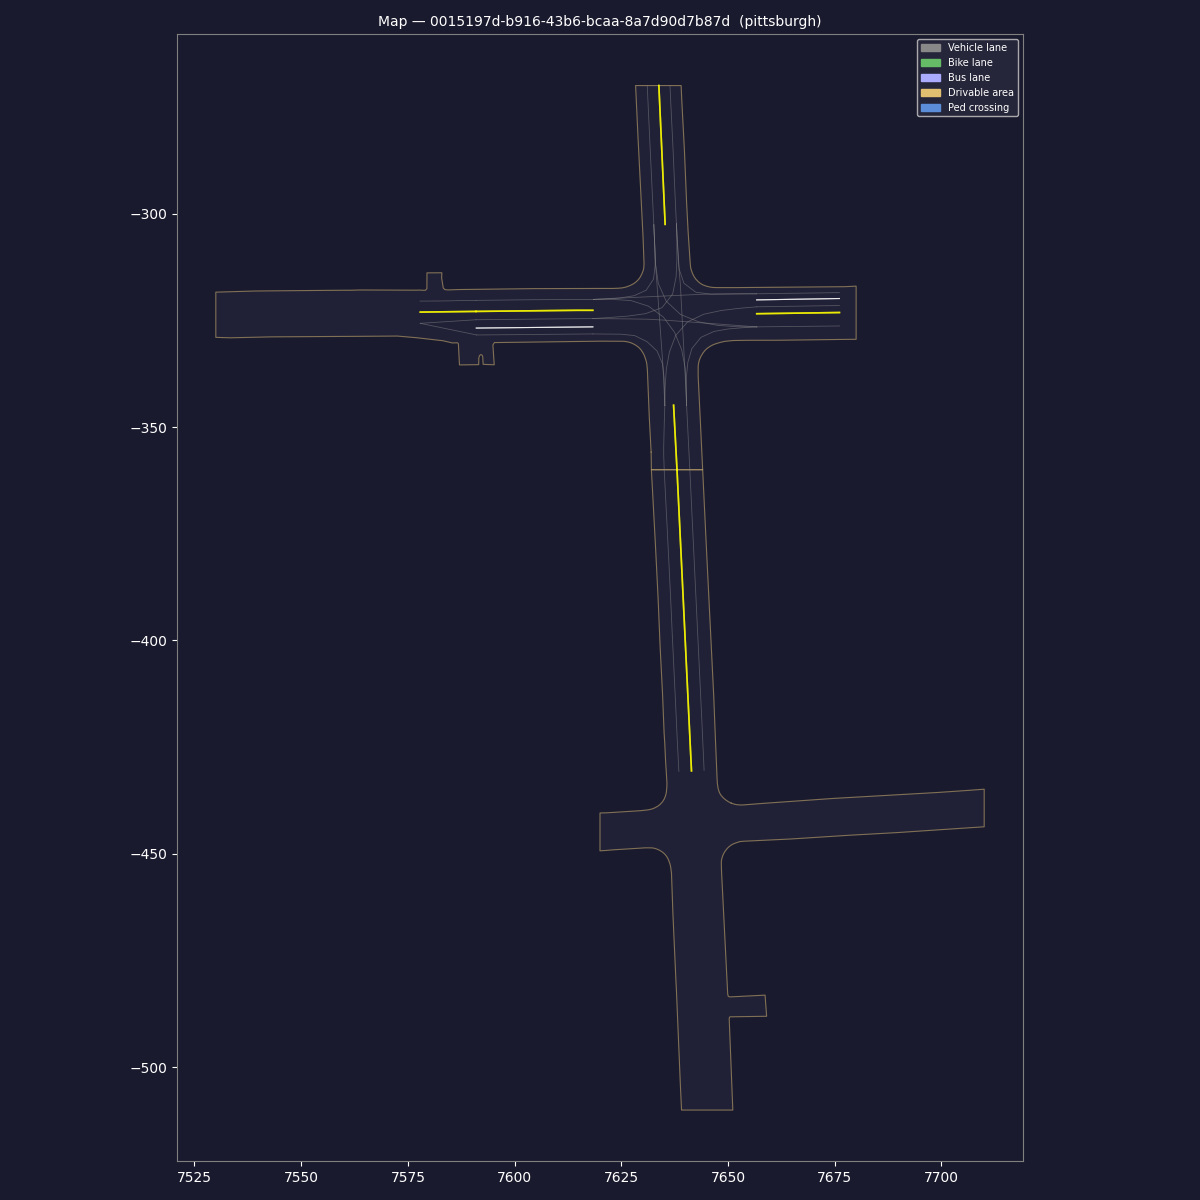

In [ ]:
"""Visualize map features."""
fig, ax = plt.subplots(figsize=(12, 12))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.set_aspect('equal')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')
ax.set_title(f'Map — {scenario.scenario_id}  ({scenario.city_name})',
             color='white', fontsize=10)

# Drivable area fill
for da in driv_areas:
    xy = da.xyz[:, :2]
    ax.fill(xy[:, 0], xy[:, 1], color='#22223a', alpha=0.8, zorder=0)
    ax.plot(xy[:, 0], xy[:, 1], color='#e0c070', lw=0.8, alpha=0.5, zorder=1)

# Lane centerlines
for ls in lanes:
    cl = avm.get_lane_segment_centerline(ls.id)[:, :2]
    c  = LANE_TYPE_COLOR.get(ls.lane_type, '#888888')
    ax.plot(cl[:, 0], cl[:, 1], color=c, lw=0.6, alpha=0.5, zorder=2)

# Lane boundaries
for ls in lanes:
    left_lane = (ls.left_lane_boundary,  ls.left_mark_type),
    right_lane = (ls.right_lane_boundary, ls.right_mark_type),

    boundaries = []
    if ls.left_mark_type != LaneMarkType.NONE:
            boundaries.append((ls.left_lane_boundary,  ls.left_mark_type))
        
    if ls.right_mark_type != LaneMarkType.NONE:
            boundaries.append((ls.right_lane_boundary, ls.right_mark_type))

    for boundary, mark_type in boundaries:
        xy = boundary.xyz[:, :2]
        st = MARK_STYLE.get(mark_type, dict(color='gray', lw=0.3, ls=':')).copy()
        ax.plot(xy[:, 0], xy[:, 1], alpha=0.7, zorder=3, **st)

# Pedestrian crossings
# for pc in ped_xings:
#     poly = pc.polygon[:, :2]
#     ax.fill(poly[:, 0], poly[:, 1], color='#5b8dd9', alpha=0.25, zorder=4)
#     ax.plot(
#         np.append(poly[:, 0], poly[0, 0]),
#         np.append(poly[:, 1], poly[0, 1]),
#         color='#5b8dd9', lw=0.6, alpha=0.6, zorder=4,
#     )

legend_items = [
    mpatches.Patch(color='#888888', label='Vehicle lane'),
    mpatches.Patch(color='#66bb66', label='Bike lane'),
    mpatches.Patch(color='#aaaaff', label='Bus lane'),
    mpatches.Patch(color='#e0c070', label='Drivable area'),
    mpatches.Patch(color='#5b8dd9', label='Ped crossing'),
]
ax.legend(handles=legend_items, loc='upper right',
          facecolor='#2a2a3e', labelcolor='white', fontsize=7)
plt.tight_layout()
plt.show()

Intersection lanes: 12 / 27 total


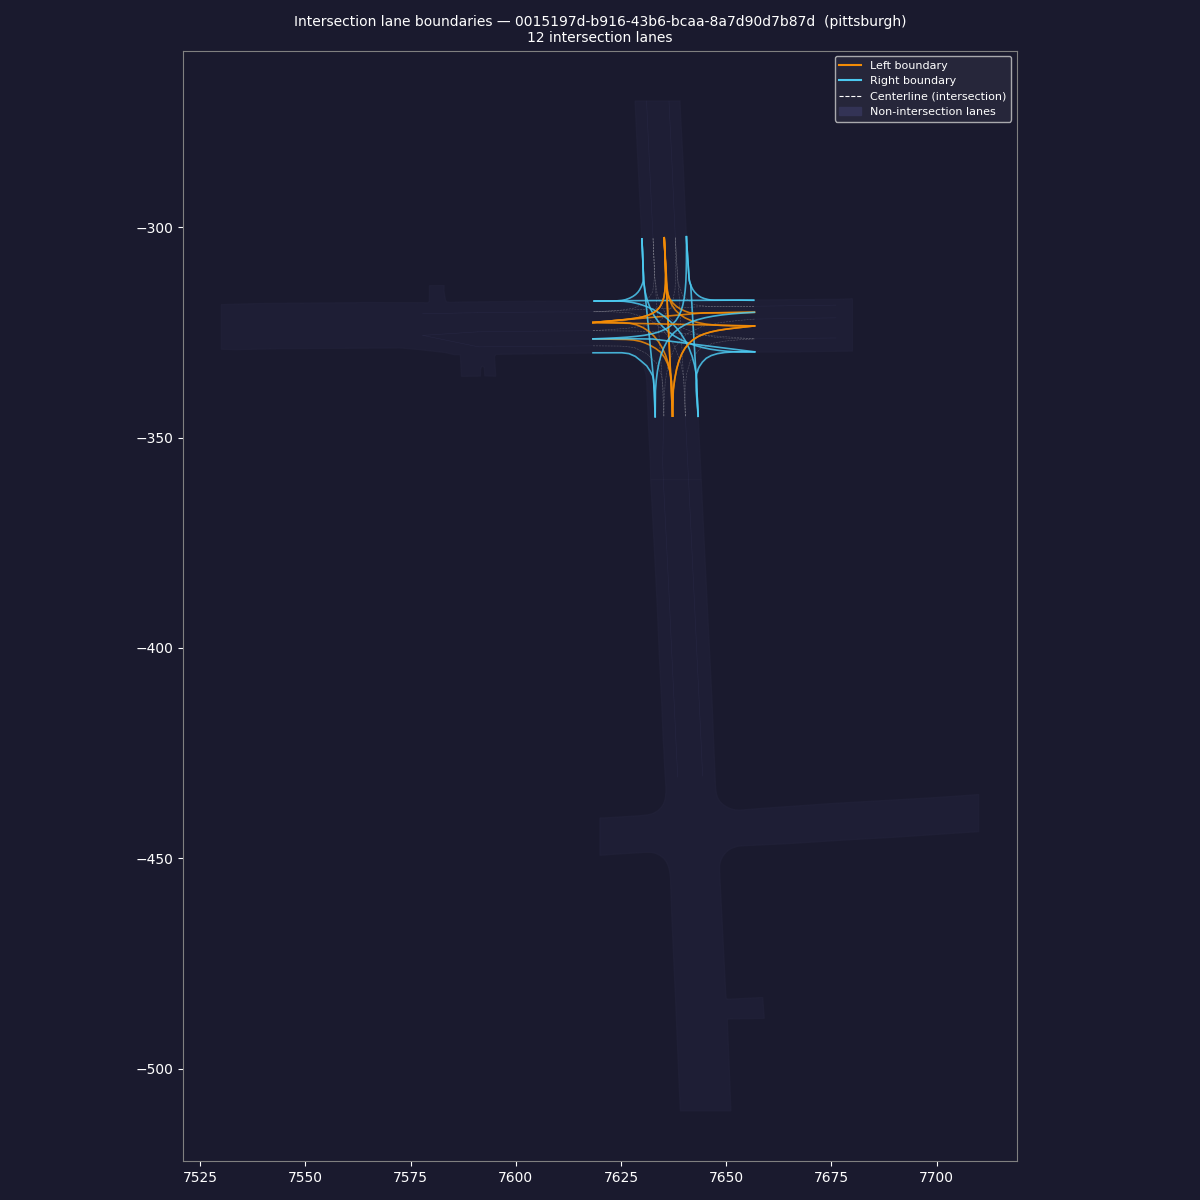

In [34]:
"""Plot left/right polylines of all intersection lanes."""
intersection_lanes = [ls for ls in lanes if ls.is_intersection]
print(f'Intersection lanes: {len(intersection_lanes)} / {len(lanes)} total')

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.set_aspect('equal')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')
ax.set_title(
    f'Intersection lane boundaries — {scenario.scenario_id}  ({scenario.city_name})\n'
    f'{len(intersection_lanes)} intersection lanes',
    color='white', fontsize=10,
)

# Faint drivable-area fill for context
for da in driv_areas:
    xy = da.xyz[:, :2]
    ax.fill(xy[:, 0], xy[:, 1], color='#22223a', alpha=0.6, zorder=0)

# Non-intersection lanes as dim background
for ls in lanes:
    if not ls.is_intersection:
        cl = avm.get_lane_segment_centerline(ls.id)[:, :2]
        ax.plot(cl[:, 0], cl[:, 1], color='#333355', lw=0.4, alpha=0.4, zorder=1)

# Intersection lane boundaries
for ls in intersection_lanes:
    left_xy  = ls.left_lane_boundary.xyz[:, :2]
    right_xy = ls.right_lane_boundary.xyz[:, :2]
    ax.plot(left_xy[:, 0],  left_xy[:, 1],  color='#f48c06', lw=1.2, alpha=0.85, zorder=3)
    ax.plot(right_xy[:, 0], right_xy[:, 1], color='#4cc9f0', lw=1.2, alpha=0.85, zorder=3)
    # Centerline faint
    cl = avm.get_lane_segment_centerline(ls.id)[:, :2]
    ax.plot(cl[:, 0], cl[:, 1], color='#ffffff', lw=0.4, alpha=0.25, ls='--', zorder=2)

legend_items = [
    plt.Line2D([0], [0], color='#f48c06', lw=1.5, label='Left boundary'),
    plt.Line2D([0], [0], color='#4cc9f0', lw=1.5, label='Right boundary'),
    plt.Line2D([0], [0], color='#ffffff', lw=0.8, ls='--', label='Centerline (intersection)'),
    mpatches.Patch(color='#333355', label='Non-intersection lanes'),
]
ax.legend(handles=legend_items, loc='upper right',
          facecolor='#2a2a3e', labelcolor='white', fontsize=8)
plt.tight_layout()
plt.show()

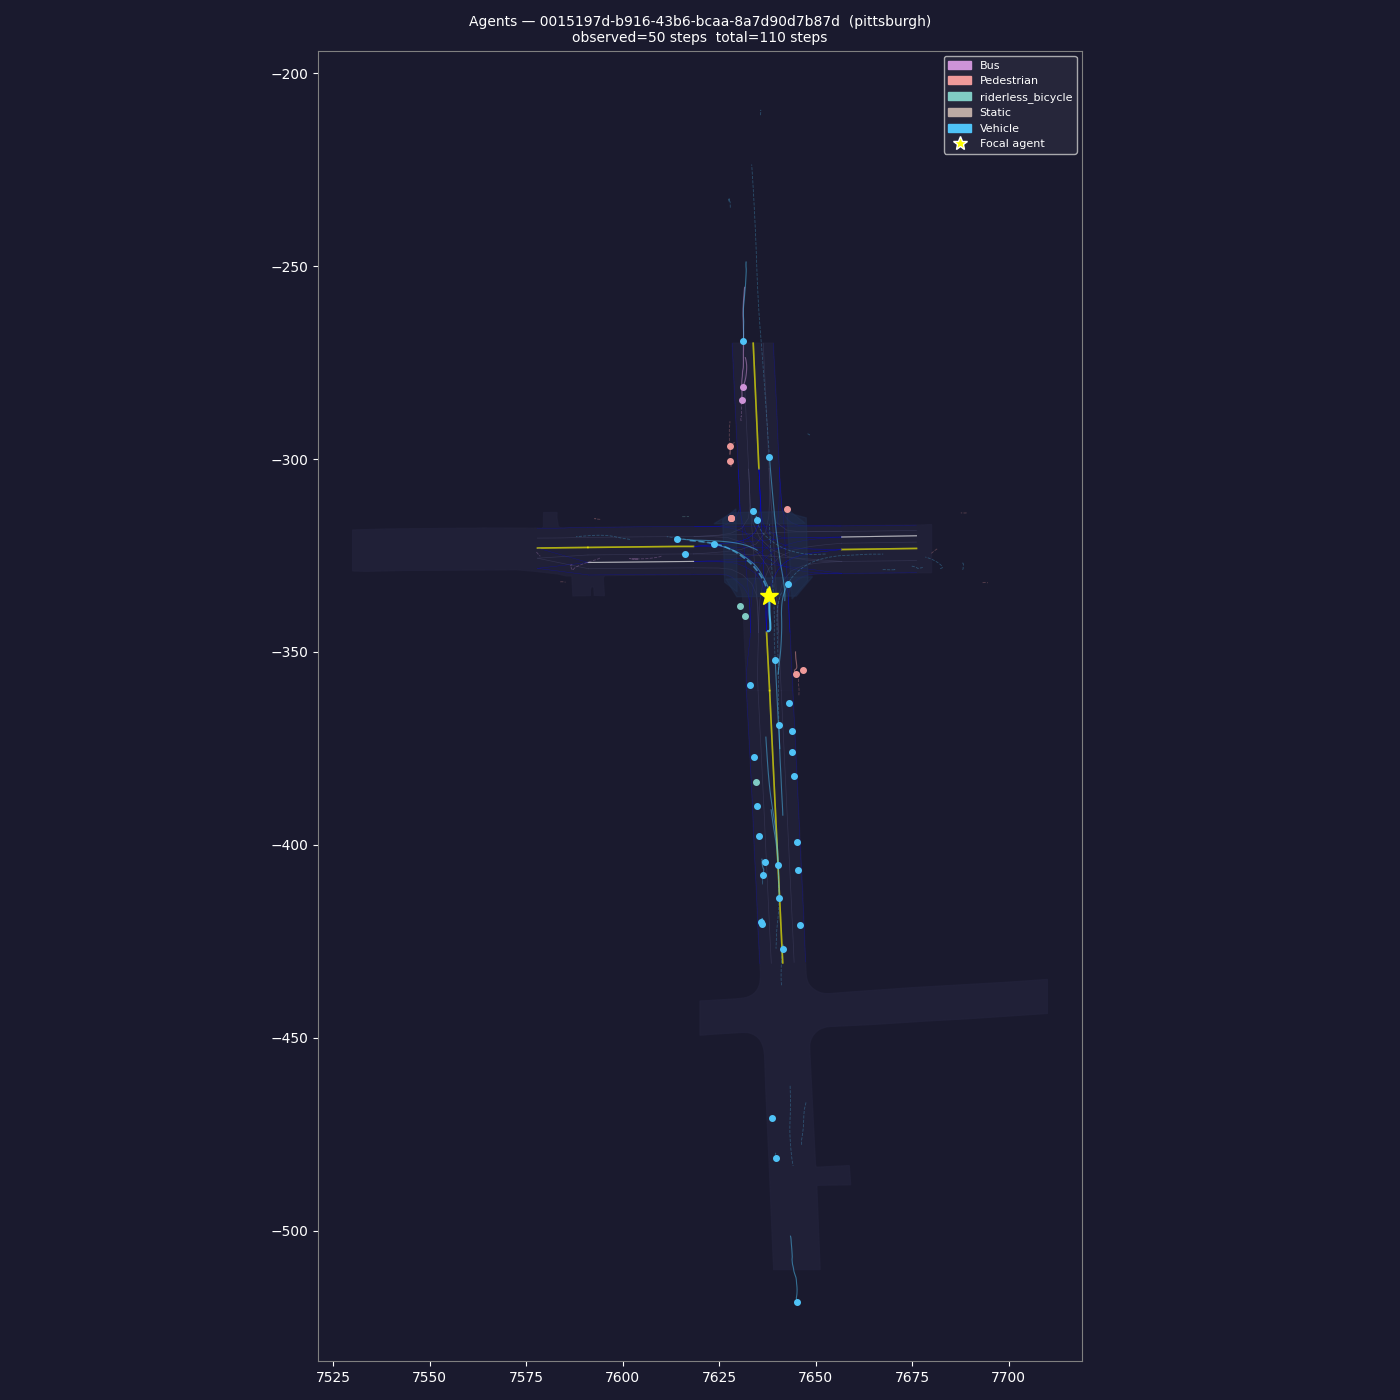

In [35]:
"""Visualize agent trajectories overlaid on the map."""
focal_id = scenario.focal_track_id

fig, ax = plt.subplots(figsize=(14, 14))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.set_aspect('equal')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')
ax.set_title(
    f'Agents — {scenario.scenario_id}  ({scenario.city_name})\n'
    f'observed={OBS_STEPS} steps  total={n_timesteps} steps',
    color='white', fontsize=10,
)

# Light map background
for da in driv_areas:
    xy = da.xyz[:, :2]
    ax.fill(xy[:, 0], xy[:, 1], color='#22223a', alpha=0.8, zorder=0)
for ls in lanes:
    cl = avm.get_lane_segment_centerline(ls.id)[:, :2]
    ax.plot(cl[:, 0], cl[:, 1], color='#444466', lw=0.5, alpha=0.5, zorder=1)
for ls in lanes:
    for boundary, mark_type in [
        (ls.left_lane_boundary,  ls.left_mark_type),
        (ls.right_lane_boundary, ls.right_mark_type),
    ]:
        xy = boundary.xyz[:, :2]
        st = MARK_STYLE.get(mark_type, dict(color='gray', lw=0.3, ls=':'))
        ax.plot(xy[:, 0], xy[:, 1], alpha=0.4, zorder=2, **st)
for pc in ped_xings:
    poly = pc.polygon[:, :2]
    ax.fill(poly[:, 0], poly[:, 1], color='#223355', alpha=0.4, zorder=2)

plotted_types = set()

for track in scenario.tracks:
    is_focal = track.track_id == focal_id
    color    = AGENT_COLOR.get(track.object_type, '#cccccc')

    # Build dense position array indexed by timestep
    pos = {s.timestep: s.position for s in track.object_states}
    hdg = {s.timestep: s.heading  for s in track.object_states}

    obs_steps  = sorted(t for t in pos if t < OBS_STEPS)
    pred_steps = sorted(t for t in pos if t >= OBS_STEPS)

    if obs_steps:
        xs = [pos[t][0] for t in obs_steps]
        ys = [pos[t][1] for t in obs_steps]
        ax.plot(xs, ys, color=color,
                lw=1.5 if is_focal else 0.8,
                alpha=0.9 if is_focal else 0.5,
                zorder=4 if is_focal else 3)

    if pred_steps:
        xs = [pos[t][0] for t in pred_steps]
        ys = [pos[t][1] for t in pred_steps]
        ax.plot(xs, ys, color=color, ls='--',
                lw=1.2 if is_focal else 0.6,
                alpha=0.6 if is_focal else 0.3,
                zorder=4 if is_focal else 3)

    # Marker at last observed step
    last_obs = obs_steps[-1] if obs_steps else None
    if last_obs is not None:
        x, y = pos[last_obs]
        h    = hdg[last_obs]
        if is_focal:
            ax.plot(x, y, '*', color='yellow', ms=14, zorder=6)
            arrow_len = 3.0
            ax.annotate('', xy=(x + arrow_len * np.cos(h), y + arrow_len * np.sin(h)),
                        xytext=(x, y),
                        arrowprops=dict(arrowstyle='->', color='yellow', lw=1.4),
                        zorder=6)
        else:
            ax.plot(x, y, 'o', color=color, ms=4, zorder=5)

    plotted_types.add(track.object_type)

legend_items = [
    mpatches.Patch(color=AGENT_COLOR.get(t, '#cccccc'),
                   label=AGENT_LABEL.get(t, t.value))
    for t in sorted(plotted_types, key=lambda x: x.value)
    if t in AGENT_COLOR
]
legend_items.append(
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='yellow',
               markersize=10, label='Focal agent', linestyle='none')
)
ax.legend(handles=legend_items, loc='upper right',
          facecolor='#2a2a3e', labelcolor='white', fontsize=8)
plt.tight_layout()
plt.show()

/tmp/ipykernel_114783/28818632.py:15: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(12, 12))


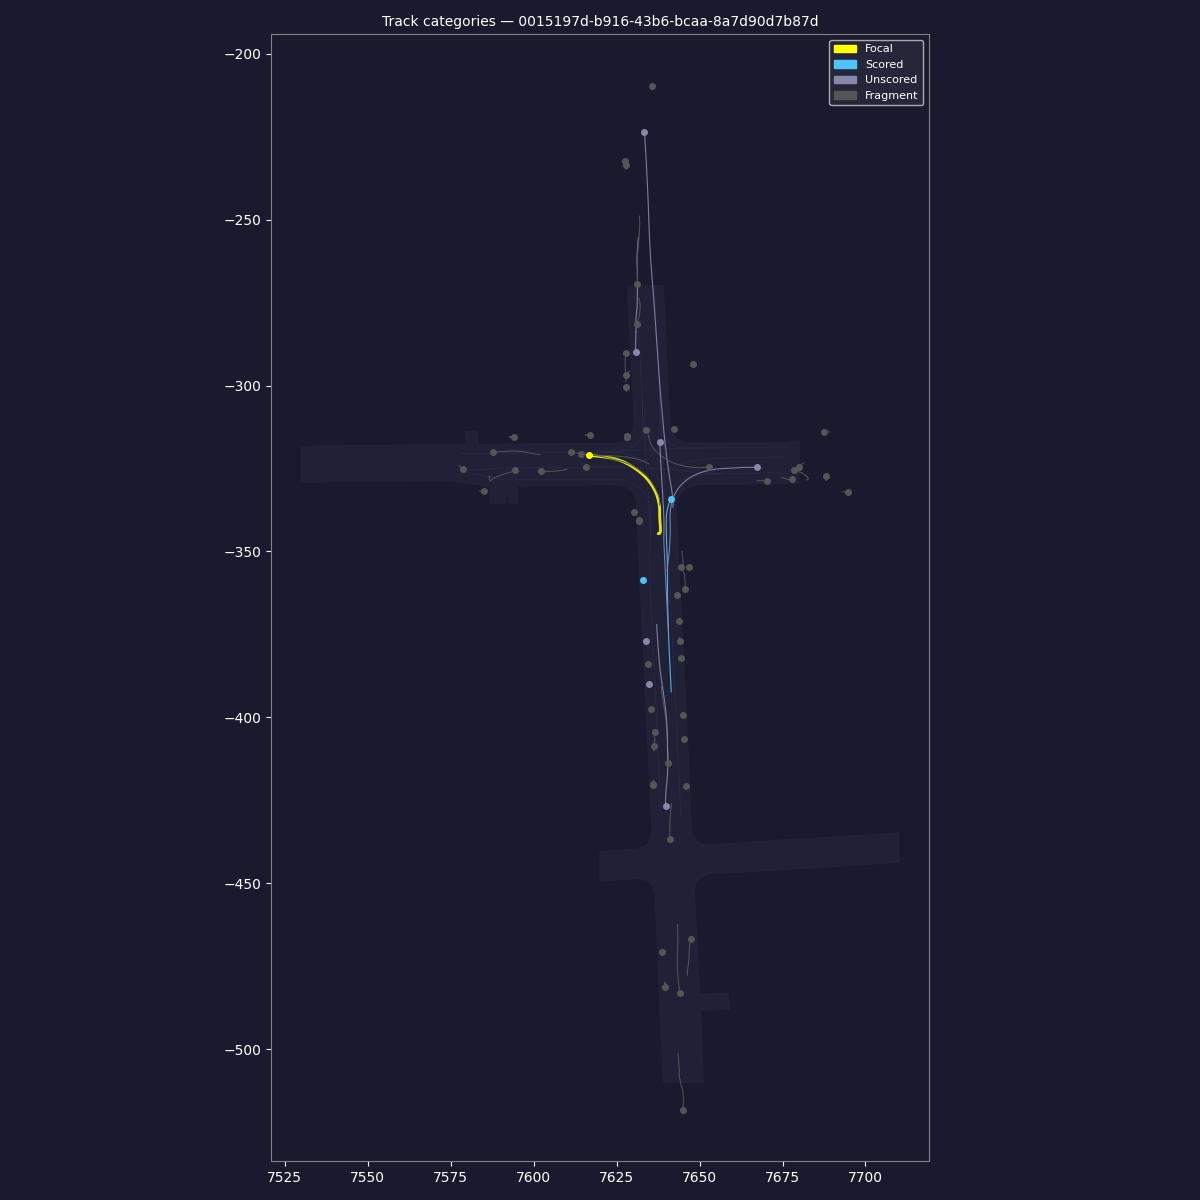

In [36]:
"""Visualize tracks colored by TrackCategory (fragment / unscored / scored / focal)."""
CAT_COLOR = {
    TrackCategory.TRACK_FRAGMENT : '#555555',
    TrackCategory.UNSCORED_TRACK : '#8888aa',
    TrackCategory.SCORED_TRACK   : '#4fc3f7',
    TrackCategory.FOCAL_TRACK    : '#ffff00',
}
CAT_LABEL = {
    TrackCategory.TRACK_FRAGMENT : 'Fragment',
    TrackCategory.UNSCORED_TRACK : 'Unscored',
    TrackCategory.SCORED_TRACK   : 'Scored',
    TrackCategory.FOCAL_TRACK    : 'Focal',
}

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.set_aspect('equal')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')
ax.set_title(f'Track categories — {scenario.scenario_id}', color='white', fontsize=10)

for da in driv_areas:
    xy = da.xyz[:, :2]
    ax.fill(xy[:, 0], xy[:, 1], color='#22223a', alpha=0.8, zorder=0)
for ls in lanes:
    cl = avm.get_lane_segment_centerline(ls.id)[:, :2]
    ax.plot(cl[:, 0], cl[:, 1], color='#333355', lw=0.5, alpha=0.5, zorder=1)

plotted_cats = set()
for track in scenario.tracks:
    color = CAT_COLOR.get(track.category, '#cccccc')
    pos   = {s.timestep: s.position for s in track.object_states}
    steps = sorted(pos)
    if not steps:
        continue
    xs = [pos[t][0] for t in steps]
    ys = [pos[t][1] for t in steps]
    lw = 2.0 if track.category == TrackCategory.FOCAL_TRACK else 0.8
    ax.plot(xs, ys, color=color, lw=lw, alpha=0.9, zorder=3)
    ax.plot(xs[-1], ys[-1], 'o', color=color, ms=4, zorder=4)
    plotted_cats.add(track.category)

legend_items = [
    mpatches.Patch(color=CAT_COLOR[c], label=CAT_LABEL[c])
    for c in [TrackCategory.FOCAL_TRACK, TrackCategory.SCORED_TRACK,
              TrackCategory.UNSCORED_TRACK, TrackCategory.TRACK_FRAGMENT]
    if c in plotted_cats
]
ax.legend(handles=legend_items, loc='upper right',
          facecolor='#2a2a3e', labelcolor='white', fontsize=8)
plt.tight_layout()
plt.show()

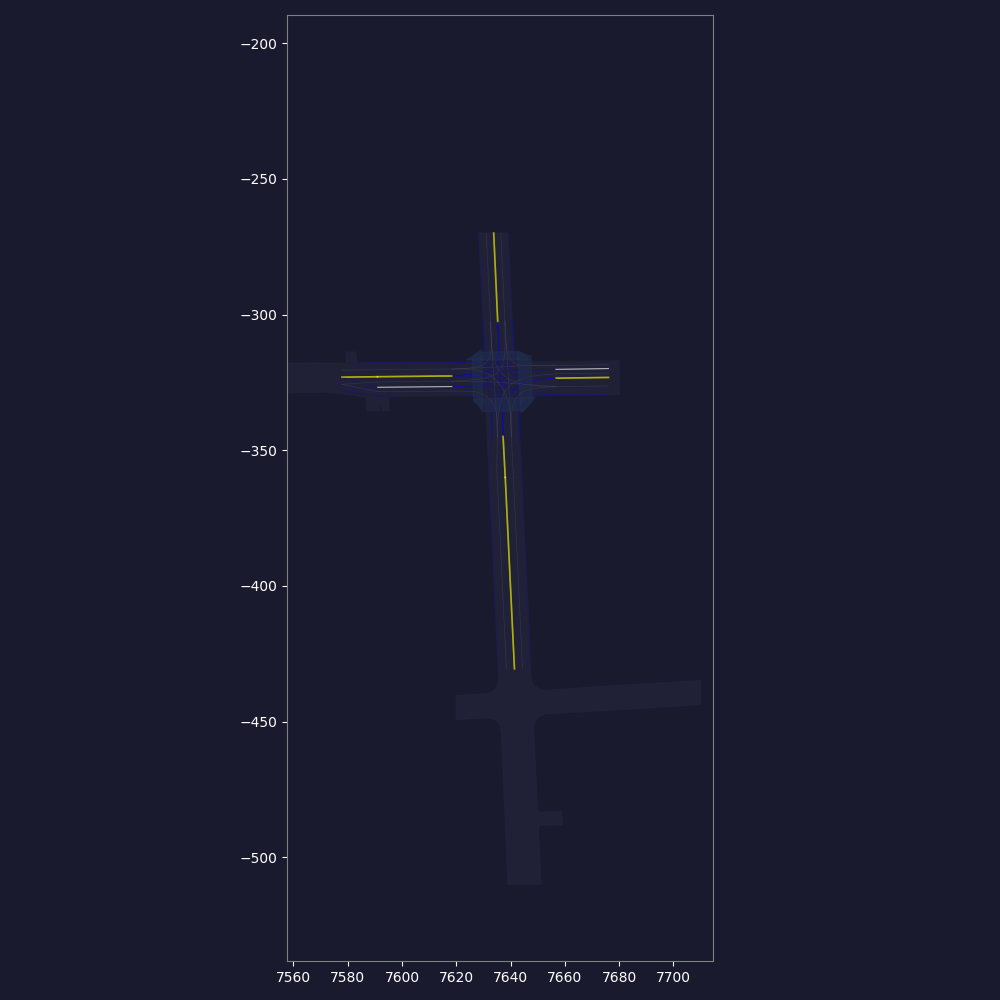

In [37]:
"""Animate agent positions through all timesteps."""
# Pre-index: track_id → array of (timestep, x, y) for fast lookup
agent_data = []
for track in scenario.tracks:
    is_focal = track.track_id == focal_id
    color    = AGENT_COLOR.get(track.object_type, '#cccccc')
    by_step  = {s.timestep: s for s in track.object_states}
    agent_data.append((by_step, color, is_focal, track.object_type))

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.set_aspect('equal')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')

# Static map
for da in driv_areas:
    xy = da.xyz[:, :2]
    ax.fill(xy[:, 0], xy[:, 1], color='#22223a', alpha=0.8, zorder=0)
for ls in lanes:
    cl = avm.get_lane_segment_centerline(ls.id)[:, :2]
    ax.plot(cl[:, 0], cl[:, 1], color='#444466', lw=0.5, alpha=0.5, zorder=1)
for ls in lanes:
    for boundary, mark_type in [
        (ls.left_lane_boundary,  ls.left_mark_type),
        (ls.right_lane_boundary, ls.right_mark_type),
    ]:
        xy = boundary.xyz[:, :2]
        st = MARK_STYLE.get(mark_type, dict(color='gray', lw=0.3, ls=':'))
        ax.plot(xy[:, 0], xy[:, 1], alpha=0.4, zorder=2, **st)
for pc in ped_xings:
    poly = pc.polygon[:, :2]
    ax.fill(poly[:, 0], poly[:, 1], color='#223355', alpha=0.4, zorder=2)

# Set axis limits from all observed positions
all_x, all_y = [], []
for by_step, _, _, _ in agent_data:
    for s in by_step.values():
        all_x.append(s.position[0])
        all_y.append(s.position[1])
margin = 20
ax.set_xlim(min(all_x) - margin, max(all_x) + margin)
ax.set_ylim(min(all_y) - margin, max(all_y) + margin)

# Scatter placeholders per object type
scatter_handles = {
    ot: ax.plot([], [], 'o', color=AGENT_COLOR.get(ot, '#cccccc'),
                ms=4, alpha=0.85, zorder=4)[0]
    for ot in ObjectType
}
focal_handle = ax.plot([], [], '*', color='yellow', ms=12, zorder=5)[0]
time_text    = ax.text(0.02, 0.97, '', transform=ax.transAxes,
                       color='white', fontsize=9, va='top')

def update(t):
    by_type = {ot: ([], []) for ot in ObjectType}
    focal_xy = ([], [])
    for by_step, color, is_focal, obj_type in agent_data:
        if t in by_step:
            x, y = by_step[t].position
            if is_focal:
                focal_xy[0].append(x)
                focal_xy[1].append(y)
            else:
                by_type[obj_type][0].append(x)
                by_type[obj_type][1].append(y)
    for ot, (xs, ys) in by_type.items():
        scatter_handles[ot].set_data(xs, ys)
    focal_handle.set_data(focal_xy[0], focal_xy[1])
    phase = 'OBS' if t < OBS_STEPS else 'PRED'
    ts_s  = scenario.timestamps_ns[t] / 1e9
    time_text.set_text(f't={ts_s:.2f}s  step {t}/{n_timesteps-1}  [{phase}]')
    return list(scatter_handles.values()) + [focal_handle, time_text]

anim = animation.FuncAnimation(fig, update, frames=n_timesteps,
                                interval=80, blit=True)
plt.tight_layout()
plt.show()